In [1]:
# installing the Kaggle library
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 98% 145M/149M [00:00<00:00, 316MB/s]
100% 149M/149M [00:00<00:00, 300MB/s]


In [4]:
!ls

brain-tumor-mri-dataset.zip  kaggle.json  sample_data


In [5]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/brain-tumor-mri-dataset.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
#import the dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

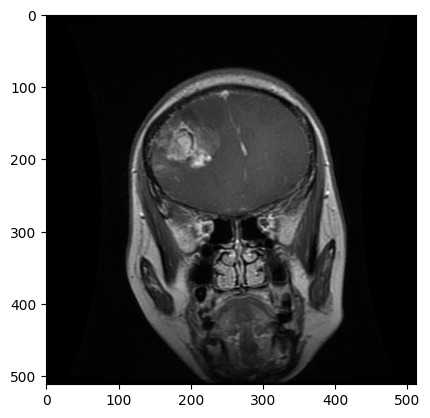

In [7]:
img = mpimg.imread('/content/Training/glioma/Tr-glTr_0000.jpg')
imgplt = plt.imshow(img)
plt.show()

In [8]:
#Load training data and testing data

filename = os.listdir('/content/Training/')
print(filename[:10])

filename1 = os.listdir('/content/Testing')
print(filename1[:5])

['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [9]:
mri_dict = {
      'pituitary':0,
      'glioma':1,
      'meningioma':2,
      'notumor':3
  }

In [10]:
data = []
mri_labels = []

for file_name in filename:
    originial_path = os.path.join('/content/Training/', file_name)
    for img_file in os.listdir(originial_path):
        image = Image.open(originial_path + "/" + img_file)
        image = image.resize((200, 200))  # Ensure consistent size
        image = np.array(image)

        # Ensure the image has 3 channels (convert grayscale to RGB by stacking)
        if len(image.shape) == 2:  # Grayscale
            image = np.stack([image] * 3, axis=-1)
        elif image.shape[-1] == 4:  # If the image has 4 channels, discard the alpha channel
            image = image[:, :, :3]  # Take only the first three channels (RGB)

        data.append(image)
        mri_labels.append(mri_dict[file_name])

for file_name in filename1:
    originial_path_te = os.path.join('/content/Testing/', file_name)
    for img_file in os.listdir(originial_path_te):
        image = Image.open(originial_path_te + "/" + img_file)
        image = image.resize((200, 200))  # Ensure consistent size
        image = np.array(image)

        # Ensure the image has 3 channels (convert grayscale to RGB by stacking)
        if len(image.shape) == 2:  # Grayscale
            image = np.stack([image] * 3, axis=-1)
        elif image.shape[-1] == 4:  # If the image has 4 channels, discard the alpha channel
            image = image[:, :, :3]  # Take only the first three channels (RGB)

        data.append(image)
        mri_labels.append(mri_dict[file_name])

# Convert data to NumPy arrays now
X = np.array(data)
Y = np.array(mri_labels)


In [11]:
type(data)

list

In [12]:
 # Y = list(mri_dict.items())
# print(Y)
type(mri_labels)

list

In [13]:
len(mri_labels)

7023

In [14]:
type(data[0])

numpy.ndarray

In [15]:
type(Y)

numpy.ndarray

In [16]:
len(X)

7023

In [17]:
#Train and test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [18]:
X_train.shape

(5618, 200, 200, 3)

In [19]:
X_test.shape

(1405, 200, 200, 3)

In [20]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [21]:
import tensorflow as tf
from tensorflow import keras

In [22]:

from tensorflow.keras.applications import DenseNet121

# Load the pre-trained DenseNet model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freeze the base model layers to prevent them from being trained
base_model.trainable = False

# Add custom layers on top of DenseNet
model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation='softmax')
])




29084464/29084464 [==============================] - 0s 0us/step


In [23]:
from tensorflow.keras.optimizers import Adam

# Compile the DenseNet model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [24]:
history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=30,batch_size=32)

Epoch 1/30
158/158 [==============================] - 87s 509ms/step - loss: 0.6858 - accuracy: 0.7379 - val_loss: 0.4272 - val_accuracy: 0.8345
Epoch 2/30
158/158 [==============================] - 78s 494ms/step - loss: 0.4325 - accuracy: 0.8358 - val_loss: 0.3228 - val_accuracy: 0.8808
Epoch 3/30
158/158 [==============================] - 74s 468ms/step - loss: 0.3522 - accuracy: 0.8726 - val_loss: 0.2844 - val_accuracy: 0.8968
Epoch 4/30
158/158 [==============================] - 72s 454ms/step - loss: 0.3155 - accuracy: 0.8833 - val_loss: 0.2932 - val_accuracy: 0.9004
Epoch 5/30
158/158 [==============================] - 67s 425ms/step - loss: 0.2910 - accuracy: 0.8922 - val_loss: 0.2699 - val_accuracy: 0.9128
Epoch 6/30
158/158 [==============================] - 72s 454ms/step - loss: 0.2729 - accuracy: 0.8993 - val_loss: 0.2413 - val_accuracy: 0.9021
Epoch 7/30
158/158 [==============================] - 65s 412ms/step - loss: 0.2580 - accuracy: 0.9072 - val_loss: 0.2296 - val_ac

In [26]:
import numpy as np
from sklearn.metrics import classification_report

# Predict on test data
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# Since Y_test is likely 1D (actual labels), no need for argmax
y_true_classes = Y_test
# If Y_test is one-hot encoded, then uncomment the line below & comment the line above
# y_true_classes = np.argmax(Y_test, axis=1)

# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

44/44 [==============================] - 17s 393ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       380
           1       0.96      0.88      0.92       313
           2       0.88      0.93      0.91       324
           3       0.98      0.99      0.99       388

    accuracy                           0.95      1405
   macro avg       0.95      0.95      0.95      1405
weighted avg       0.95      0.95      0.95      1405



In [28]:
# Extract class names from mri_dict
class_names = list(mri_dict.keys())

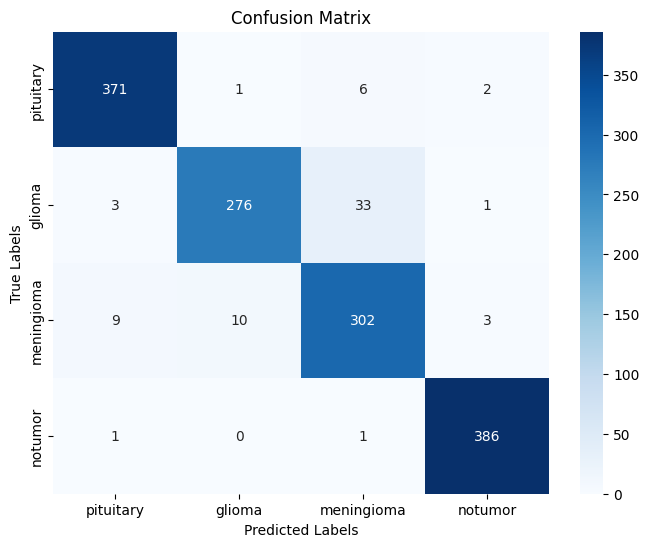

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [41]:
import numpy as np
import tensorflow as tf

def predict_image_class(image_path):
    """
    Predicts the class of an image using the trained DenseNet model.

    Args:
      image_path: Path to the image file.

    Returns:
      The predicted class name.
    """
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(200, 200))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.

    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]

    return predicted_class_name

# Example: Predict a single image class
predict_image_class('/content/Testing/glioma/Te-glTr_0000.jpg')


1/1 [==============================] - 0s 87ms/step


'glioma'

In [33]:
# Import required libraries
import pickle

# Save model weights and architecture separately using pickle
filename = 'brain_tumor_densenet_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump({
        'model_architecture': base_model.to_json(),  # Save model architecture
        'model_weights': base_model.get_weights()    # Save model weights
    }, f)


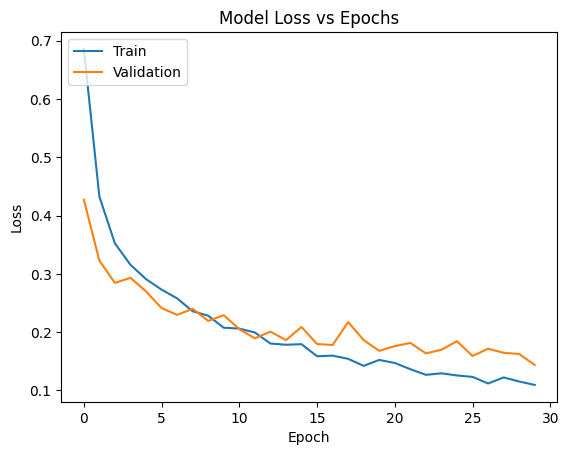

In [34]:
import matplotlib.pyplot as plt

# Plot loss vs epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


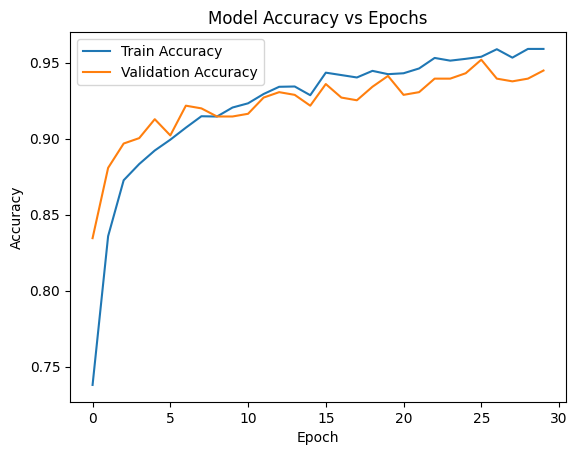

In [44]:
import matplotlib.pyplot as plt

# Plot the accuracy for both training and validation
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [45]:
# Save the entire model as an H5 file
base_model.save('brain_tumor_densenet_model.h5')

# Download the model in Google Colab
from google.colab import files
files.download('brain_tumor_densenet_model.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import numpy as np
import tensorflow as tf
from google.colab import files

def predict_image_class_from_upload():
    # Upload image
    uploaded = files.upload()
    for fn in uploaded.keys():
        image_path = fn

        # Preprocess the image
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=(200, 200))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Normalize the image

        # Make prediction
        prediction = base_model.predict(img_array)

        # Check if prediction shape is as expected (e.g., (1, num_classes))
        print("Prediction shape:", prediction.shape)

        predicted_class_index = np.argmax(prediction[0]) # Get index from the first (and only) prediction

        # Ensure predicted_class_index is within the valid range
        predicted_class_index = min(predicted_class_index, len(class_names) - 1)

        # Assuming `class_names` is derived from `mri_dict`
        predicted_class_name = class_names[predicted_class_index]

        print(f"The predicted class for the uploaded image is: {predicted_class_name}")

# Call the function to upload and predict the class
predict_image_class_from_upload()

Saving Te-glTr_0000.jpg to Te-glTr_0000 (7).jpg
1/1 [==============================] - 0s 80ms/step
Prediction shape: (1, 6, 6, 1024)
The predicted class for the uploaded image is: notumor
